# SDM-VA-ISAC — Phase 2 : Sionna RT Pipeline sur scene.xml

**Projet :** *Semantic Digital Mapping using Vision-Assisted ISAC*  
**Phase :** 2 — Scène Blender/OSM→XML + calibration Sionna RT  
**Scène :** `scene/scene.xml` exportée depuis Blender via Mitsuba-Blender add-on (OSM map_5)  
**Zone :** Secteur gouvernemental de Rabat (Conseil Économique, Cour des Comptes…)

### Objectifs de ce notebook
1. Charger `scene.xml` dans Sionna RT avec variante GPU `cuda_ad_mono_polarized`
2. Configurer les paramètres RF : 3.5 GHz (5G mid-band) ou 28 GHz (mmWave)
3. Déployer BS (TX) et UE (RX), lancer le ray tracing
4. Extraire CIR, délais, puissances — sorties ISAC pour la Phase 3
5. Visualiser PDP, couverture de puissance, trajets

### Critères de validation Phase 2
- [ ] Scène XML chargée sans erreur
- [ ] PathSolver retourne des chemins exploitables
- [ ] CIR extrait avec dimensions cohérentes
- [ ] Graphe PDP (Power Delay Profile) généré
- [ ] `phase2_sionna_rt_summary.json` produit pour la Phase 3

## 1. Imports et configuration de l'environnement

In [1]:
from __future__ import annotations

import json
import time
import importlib.metadata
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Mitsuba : variante GPU (RTX 4070 → cuda_ad_mono_polarized)
# Sionna RT 2.x nécessite 'mono_polarized', PAS 'rgb'
import mitsuba as mi

try:
    mi.set_variant("cuda_ad_mono_polarized")
    print(f"Variante GPU activée : {mi.variant()}")
except Exception as e:
    print(f"CUDA indisponible ({e}), repli sur LLVM CPU")
    mi.set_variant("llvm_ad_mono_polarized")
    print(f"Variante CPU activée : {mi.variant()}")

# ── Sionna RT 2.0.1
import sionna
from sionna.rt import (
    load_scene,
    Transmitter, Receiver,
    PlanarArray,
    PathSolver,
    RadioMapSolver, PlanarRadioMap,
    Camera,
)

# sionna.__init__ n'expose pas __version__ (paquet 2.0.1) → lire via importlib.metadata
SIONNA_VERSION = importlib.metadata.version("sionna")
print(f"Sionna version : {SIONNA_VERSION}")

# ── Chemins
WORKSPACE = Path(r"C:\Users\AdminFix\Desktop\PFA")
SCENE_XML  = WORKSPACE / "scene" / "scene.xml"   # scène OSM (map_5) exportée depuis Blender

# ── Paramètres RF
FREQUENCY_HZ  = 3.5e9    # 3.5 GHz — 5G NR mid-band (changer à 28e9 pour mmWave)
BANDWIDTH_HZ  = 20e6     # 20 MHz
MAX_DEPTH     = 5        # profondeur max des trajets (réflexions + diffractions)

assert SCENE_XML.exists(), f"Fichier introuvable : {SCENE_XML}"
print(f"Scène : {SCENE_XML}")
print(f"Fréquence : {FREQUENCY_HZ/1e9:.1f} GHz | BW : {BANDWIDTH_HZ/1e6:.0f} MHz")

jitc_llvm_init(): LLVM API initialization failed ..


Variante GPU activée : cuda_ad_mono_polarized
Sionna version : 2.0.1
Scène : C:\Users\AdminFix\Desktop\PFA\scene\scene.xml
Fréquence : 3.5 GHz | BW : 20 MHz


## 2. Chargement de la scène scene.xml

La scène contient les maillages PLY des bâtiments avec matériaux ITU :
- `itu_concrete` → sol (Plane.ply)
- `itu_marble` → façades de bâtiments
- `itu_metal` → toits et éléments métalliques

Sionna RT reconnaît automatiquement les matériaux préfixés `itu_`.

In [2]:
print("Chargement de la scène...")
t0 = time.time()

scene = load_scene(
    str(SCENE_XML),
    merge_shapes=True,
    remove_duplicate_vertices=False,
)

print(f"Scène chargée en {time.time()-t0:.2f} s")
print(f"Objets dans la scène : {list(scene.objects.keys())[:10]}...")
print(f"Matériaux radio : {list(scene.radio_materials.keys())}")

scene.frequency = FREQUENCY_HZ
scene.bandwidth = BANDWIDTH_HZ
# Utiliser les variables Python directement (scene.frequency retourne mi.Float)
print(f"\nFréquence scène : {FREQUENCY_HZ/1e9:.2f} GHz")
print(f"Bande passante  : {BANDWIDTH_HZ/1e6:.0f} MHz")

Chargement de la scène...
Scène chargée en 0.81 s
Objets dans la scène : ['elm__3', 'elm__6', 'elm__7']...
Matériaux radio : ['itu_concrete', 'itu_marble', 'itu_metal']

Fréquence scène : 3.50 GHz
Bande passante  : 20 MHz


## 3. Configuration des réseaux d'antennes et placement des équipements

- **BS (TX)** : réseau planaire 4×4, dual-polarisé, hauteur 25 m (macro-cellule)
- **UE (RX)** : antenne simple, hauteur 1.5 m (piéton/véhicule)

Les positions sont en mètres dans le repère local Blender.
Ajustez `TX_POS` et `RX_POSITIONS` selon votre carte OSM.

In [3]:
# ── Positions TX/RX mesurées manuellement dans Blender (repère scene.xml, Y forward / Z up,
# donc pas de conversion d'axes nécessaire à l'export). Pas de bbox générique ici :
# ces coordonnées viennent directement du panneau de transform Blender pour ce scene.xml.

# ── Réseaux d'antennes
bs_array = PlanarArray(
    num_rows=4, num_cols=4,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="VH",
)
ue_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="V",
)
scene.tx_array = bs_array
scene.rx_array = ue_array

# ── BS principale (bs0), position mesurée manuellement dans Blender
TX_POS = [-258.774, 30.3715, 233.978]

# ── UE à hauteur piéton/véhicule, dispersés dans la scène (positions Blender)
RX_POSITIONS = [
    [ -288.25 ,  65.1737 , 186],    # UE0
    [ -349.365 , -13.8654 , 133.457],   # UE1
    [ -442.437 , 149.609, 197.122 ],   # UE2
    [-118.702, 277.4, 255.7],   # UE3
    [-5.512 ,  -221.3, 197.1],   # UE4
]

# ── Deuxième BS (bs1), position mesurée manuellement dans Blender (+3 m de support)
TX_POS2 = [66.1771, -148.4, 216.4 + 3.0]

# ── Deuxième UE (ue5), position mesurée manuellement dans Blender
RX_POS2 = [-163.6, 236.0, 199.1]

TX_POSITIONS = [TX_POS, TX_POS2]
RX_POSITIONS = RX_POSITIONS + [RX_POS2]

# ── Ajouter à la scène (idempotent : retire tout TX/RX homonyme avant d'ajouter,
# pour pouvoir ré-exécuter cette cellule sans recharger la scène à chaque fois)
tx_names = [f"bs{i}" for i in range(len(TX_POSITIONS))]
rx_names = [f"ue{i}" for i in range(len(RX_POSITIONS))]
for stale_name in tx_names + rx_names:
    if stale_name in scene.transmitters or stale_name in scene.receivers:
        scene.remove(stale_name)

for i, pos in enumerate(TX_POSITIONS):
    scene.add(Transmitter(name=f"bs{i}", position=pos))
    print(f"TX ajouté : bs{i} @ {pos}")

for i, pos in enumerate(RX_POSITIONS):
    scene.add(Receiver(name=f"ue{i}", position=pos))
    print(f"RX ajouté : ue{i} @ {pos}")

print(f"\nTotal TX : {len(scene.transmitters)} | Total RX : {len(scene.receivers)}")

TX ajouté : bs0 @ [-258.774, 30.3715, 233.978]
TX ajouté : bs1 @ [66.1771, -148.4, 219.4]
RX ajouté : ue0 @ [-288.25, 65.1737, 186]
RX ajouté : ue1 @ [-349.365, -13.8654, 133.457]
RX ajouté : ue2 @ [-442.437, 149.609, 197.122]
RX ajouté : ue3 @ [-118.702, 277.4, 255.7]
RX ajouté : ue4 @ [-5.512, -221.3, 197.1]
RX ajouté : ue5 @ [-163.6, 236.0, 199.1]

Total TX : 2 | Total RX : 6


## 4. Lancer de rayons (Ray Tracing)

Le `PathSolver` calcule tous les trajets entre TX et RX :
- **LOS** : trajet en ligne de vue directe
- **Specular reflection** : réflexions spéculaires sur façades
- **Diffraction** : contournement des arêtes de bâtiments
- **Diffuse reflection** : activée pour des scènes plus réalistes (coûteux)

> Pour `max_depth=5` : jusqu'à 4 réflexions + 1 diffraction par trajet.

In [4]:
solver = PathSolver()

print(f"Calcul des trajets (max_depth={MAX_DEPTH})...")
t0 = time.time()

paths = solver(
    scene,
    max_depth=MAX_DEPTH,
    los=True,                   # trajets LOS
    specular_reflection=True,   # réflexions spéculaires
    diffuse_reflection=False,   # désactivé (activer pour + de réalisme)
    refraction=False,           # désactivé (bâtiments opaques)
    diffraction=True,           # diffraction sur arêtes
    edge_diffraction=False,     # diffraction sur arêtes flottantes
    seed=42,
)

elapsed = time.time() - t0
print(f"Ray tracing terminé en {elapsed:.2f} s")

# Afficher les infos sur les trajets trouvés
tau_raw = np.array(paths.tau)   # [num_rx, num_tx, num_paths] (synthetic_array=True)
print(f"\nShape tau : {tau_raw.shape}  → [num_rx, num_tx, num_paths]")
print(f"Nombre de trajets par lien RX-TX : {tau_raw.shape[-1]}")

# Compter les trajets valides (tau > 0)
valid_mask = tau_raw > 0
print(f"Trajets valides : {valid_mask.sum()} / {valid_mask.size}")

Calcul des trajets (max_depth=5)...
Ray tracing terminé en 0.20 s

Shape tau : (6, 2, 232)  → [num_rx, num_tx, num_paths]
Nombre de trajets par lien RX-TX : 232
Trajets valides : 1171 / 2784


## 4bis. Visualisation 3D des trajets

Deux façons de visualiser la scène et les trajets en 3D avec Sionna RT :
- `scene.preview(paths=paths)` : widget **interactif** (rotation/zoom à la souris) — fonctionne uniquement dans une session Jupyter **live** avec support WebGL (pas via `nbconvert --execute`/export PDF, qui n'a pas de frontend interactif).
- `scene.render(camera=..., paths=paths)` : rendu **statique** (image) — fonctionne partout, y compris en exécution batch, et peut être sauvegardé en PNG.

Le flag `no_preview` bascule automatiquement entre les deux (même pattern que le tutoriel officiel Sionna RT).

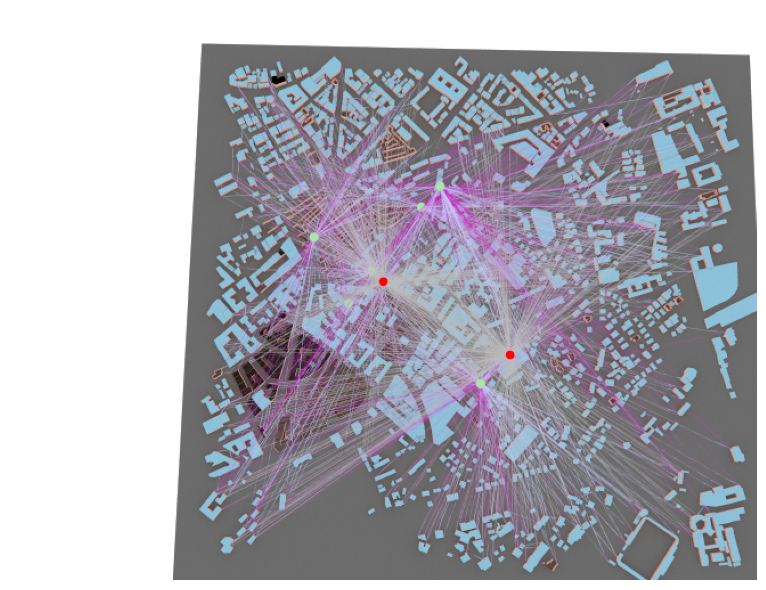

In [13]:
# ── Bascule : True pour export batch/PDF (image statique), False en session Jupyter live (widget interactif)
no_preview = True

# ── Caméra positionnée en vue aérienne oblique, centrée sur la BS
scene_bbox = scene.mi_scene.bbox()
center_x = float((scene_bbox.min[0] + scene_bbox.max[0]) / 2)
center_y = float((scene_bbox.min[1] + scene_bbox.max[1]) / 2)

my_cam = Camera(
    position=[center_x - 300, center_y - 300, 2500],
    look_at=[TX_POS[0], TX_POS[1], 0.0],
)

if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20, num_samples=256)
else:
    scene.preview(paths=paths, clip_at=20)

## 5. Extraction de la réponse impulsionnelle (CIR)

`paths.cir()` retourne le CIR en bande de base équivalente :
- `a` = tuple `(a_real, a_imag)` — coefficients complexes de chaque trajet
- `tau` = délais [s]
- Shape : `[num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]`

Pour le ISAC : on extrait délai, puissance, et DoA de chaque trajet.

In [6]:
# CIR en bande de base — out_type="numpy" retourne un tableau complexe directement
# a_complex : [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
# tau_cir   : [num_rx, num_tx, num_paths]  (synthetic_array=True)
a_complex, tau_cir = paths.cir(
    sampling_frequency=BANDWIDTH_HZ,
    num_time_steps=1,
    normalize_delays=True,      # premier trajet à τ=0 par paire TX-RX
    out_type="numpy",
)

print("CIR extrait :")
print(f"  a_complex.shape : {a_complex.shape}")
print(f"  a_complex.dtype : {a_complex.dtype}")
print(f"  tau_cir.shape   : {tau_cir.shape}")

num_rx   = a_complex.shape[0]
num_tx   = a_complex.shape[2]
num_path = a_complex.shape[4]

print(f"\n  num_rx={num_rx}, num_tx={num_tx}, num_paths={num_path}")

# ── Statistiques pour le lien UE0 ← BS0
# a_complex[rx, rx_ant, tx, tx_ant, paths, time]
a_link   = a_complex[0, :, 0, :, :, 0]   # [rx_ant, tx_ant, num_paths]
tau_link = tau_cir[0, 0, :]               # [num_paths]

power_link  = np.abs(a_link)**2
total_power = power_link.sum()
valid_mask  = tau_link >= 0

print(f"\nLien UE0←BS0 :")
print(f"  Trajets valides         : {valid_mask.sum()} / {num_path}")
print(f"  Puissance totale reçue  : {10*np.log10(total_power + 1e-30):.1f} dB (rel.)")
if valid_mask.sum() > 0:
    print(f"  Délai max               : {1e9 * tau_link[valid_mask].max():.1f} ns")
    print(f"  Délai moyen (RMS)       : {1e9 * np.sqrt(np.mean(tau_link[valid_mask]**2)):.1f} ns")

CIR extrait :
  a_complex.shape : (6, 1, 2, 32, 232, 1)
  a_complex.dtype : complex64
  tau_cir.shape   : (6, 2, 232)

  num_rx=6, num_tx=2, num_paths=232

Lien UE0←BS0 :
  Trajets valides         : 153 / 232
  Puissance totale reçue  : -94.9 dB (rel.)
  Délai max               : 4214.6 ns
  Délai moyen (RMS)       : 2081.1 ns


## 6. Visualisation : Power Delay Profile (PDP)

Le PDP montre la distribution de puissance des trajets en fonction du délai.
Chaque pic correspond à un trajet distinct (LOS, réflexion, diffraction).

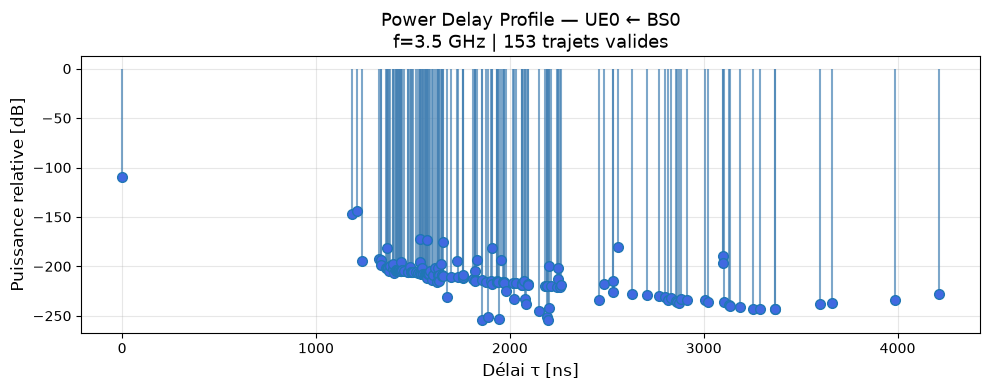

PDP sauvegardé → pdp_ue0_bs0.png


In [7]:
def plot_pdp(a_cplx: np.ndarray, tau_arr: np.ndarray,
             rx_idx: int = 0, tx_idx: int = 0,
             title: str | None = None):
    """Power Delay Profile pour un lien TX→RX donné.
    a_cplx  : [num_rx, rx_ant, num_tx, tx_ant, num_paths, num_time]
    tau_arr : [num_rx, num_tx, num_paths]
    """
    a_sel   = a_cplx[rx_idx, :, tx_idx, :, :, 0]   # [rx_ant, tx_ant, paths]
    tau_sel = tau_arr[rx_idx, tx_idx, :]             # [paths]

    power   = np.abs(a_sel)**2
    power   = power.mean(axis=(0, 1))               # moyenne antennes → [paths]

    valid   = tau_sel >= 0
    tau_ns  = tau_sel[valid] * 1e9
    pwr_db  = 10 * np.log10(power[valid] + 1e-30)

    order   = np.argsort(tau_ns)
    tau_ns  = tau_ns[order]
    pwr_db  = pwr_db[order]

    label = title or f"UE{rx_idx} ← BS{tx_idx}"
    fig, ax = plt.subplots(figsize=(10, 4))

    if len(tau_ns) == 0:
        # Aucun trajet valide (lien bloqué / hors de portée) — éviter le crash de ax.stem sur un array vide
        ax.text(0.5, 0.5, "Aucun trajet valide (lien bloqué)",
                ha="center", va="center", transform=ax.transAxes, fontsize=12, color="crimson")
    else:
        markerline, stemlines, baseline = ax.stem(tau_ns, pwr_db, basefmt=" ")
        markerline.set_markerfacecolor("royalblue")
        markerline.set_markersize(7)
        plt.setp(stemlines, color="steelblue", alpha=0.7)

    ax.set_xlabel("Délai τ [ns]", fontsize=12)
    ax.set_ylabel("Puissance relative [dB]", fontsize=12)
    ax.set_title(f"Power Delay Profile — {label}\n"
                 f"f={FREQUENCY_HZ/1e9:.1f} GHz | {len(tau_ns)} trajets valides",
                 fontsize=13)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_pdp(a_complex, tau_cir, rx_idx=0, tx_idx=0)
plt.savefig(WORKSPACE / "pdp_ue0_bs0.png", dpi=150, bbox_inches="tight")
plt.show()
print("PDP sauvegardé → pdp_ue0_bs0.png")

## 7. Comparaison PDP — tous les UE

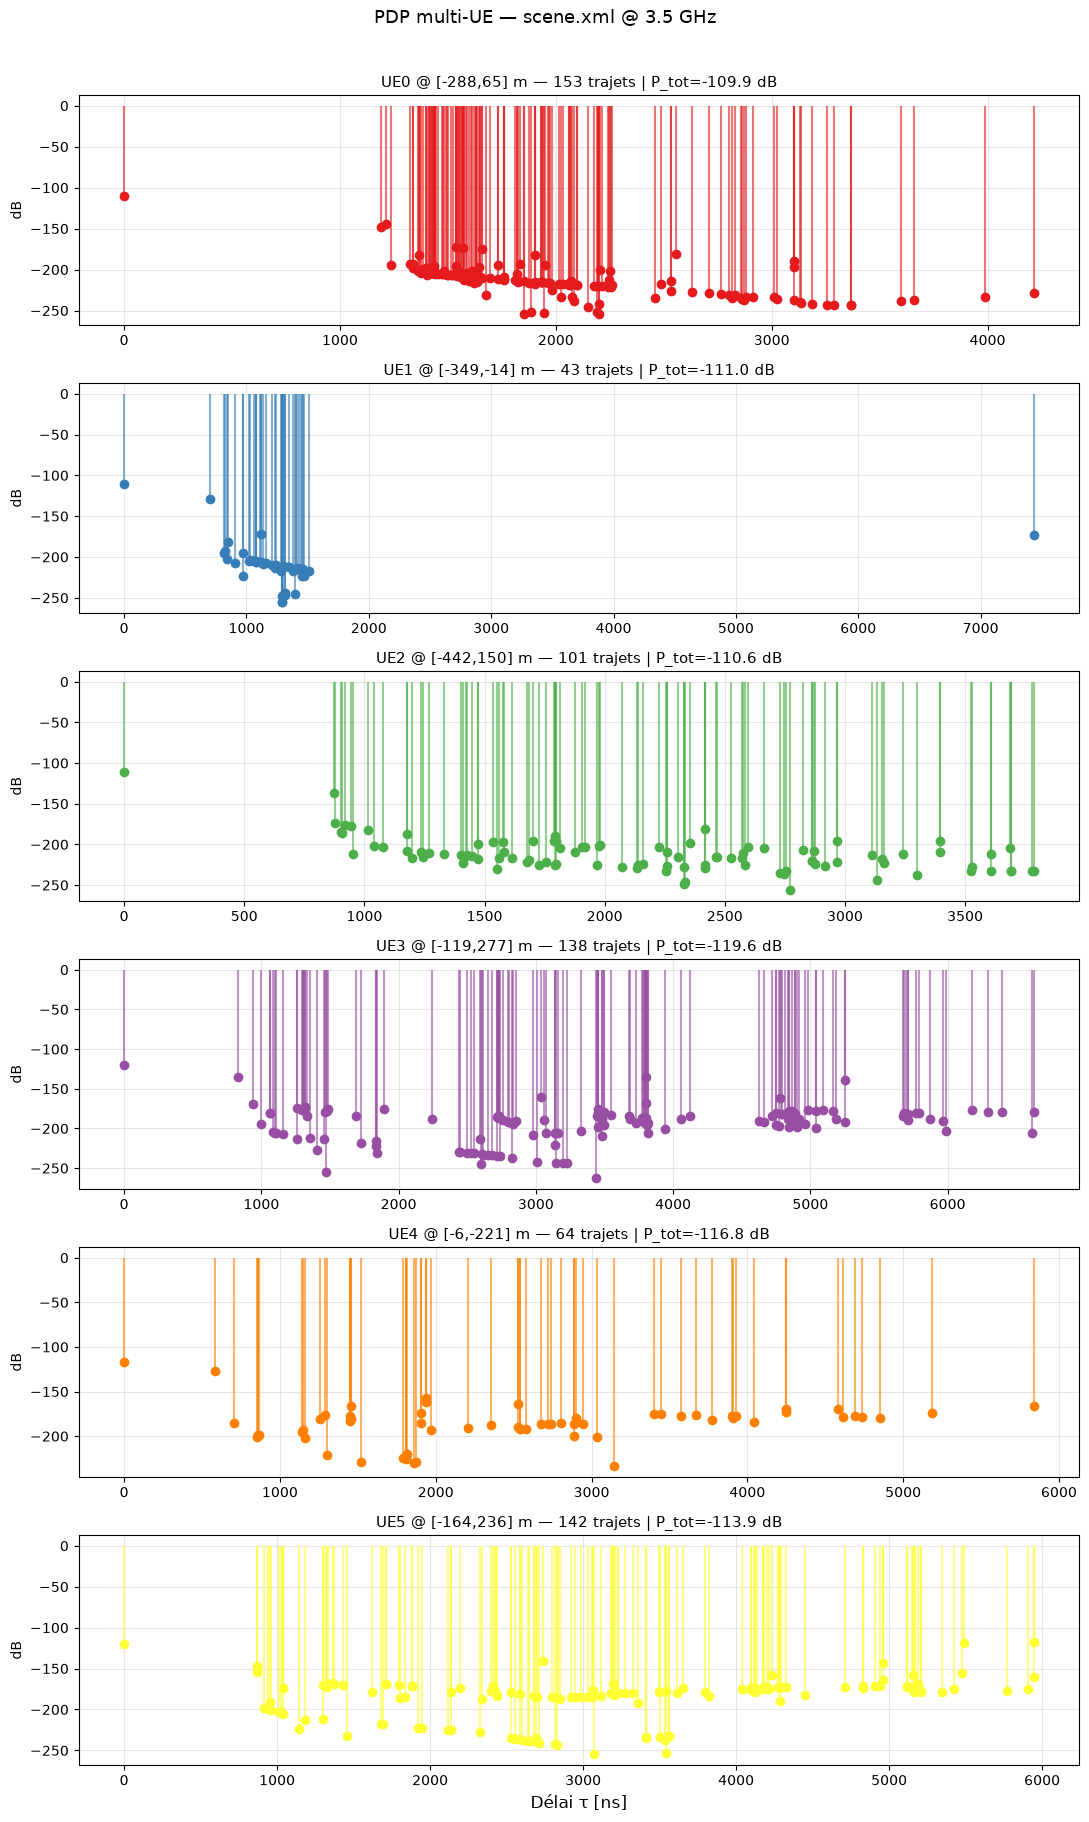

PDP multi-UE sauvegardé → pdp_all_ue.png


In [8]:
num_ue = len(RX_POSITIONS)
fig, axes = plt.subplots(num_ue, 1, figsize=(11, 3 * num_ue), sharex=False)

for rx_i, ax in enumerate(axes):
    a_sel   = a_complex[rx_i, :, 0, :, :, 0]   # [rx_ant, tx_ant, paths]
    tau_sel = tau_cir[rx_i, 0, :]               # [paths]

    power   = np.abs(a_sel)**2
    power   = power.mean(axis=(0, 1))           # [paths]

    valid   = tau_sel >= 0
    tau_ns  = tau_sel[valid] * 1e9
    pwr_db  = 10 * np.log10(power[valid] + 1e-30)

    order   = np.argsort(tau_ns)
    tau_ns  = tau_ns[order]
    pwr_db  = pwr_db[order]

    pos_str = f"[{RX_POSITIONS[rx_i][0]:.0f},{RX_POSITIONS[rx_i][1]:.0f}] m"

    if len(tau_ns) == 0:
        # Lien bloqué : aucun trajet — éviter le crash de ax.stem sur un array vide
        ax.text(0.5, 0.5, "Aucun trajet valide (lien bloqué)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="crimson")
        ax.set_title(f"UE{rx_i} @ {pos_str} — 0 trajet", fontsize=11)
    else:
        colors  = plt.cm.Set1.colors
        ml, sl, bl = ax.stem(tau_ns, pwr_db, basefmt=" ")
        plt.setp(ml, color=colors[rx_i % len(colors)], markersize=6)
        plt.setp(sl, color=colors[rx_i % len(colors)], alpha=0.6)

        tot_p = 10 * np.log10(power.sum() + 1e-30)
        ax.set_title(f"UE{rx_i} @ {pos_str} — {len(tau_ns)} trajets | P_tot={tot_p:.1f} dB",
                     fontsize=11)

    ax.set_ylabel("dB", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Délai τ [ns]", fontsize=12)
fig.suptitle(f"PDP multi-UE — scene.xml @ {FREQUENCY_HZ/1e9:.1f} GHz",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(WORKSPACE / "pdp_all_ue.png", dpi=150, bbox_inches="tight")
plt.show()
print("PDP multi-UE sauvegardé → pdp_all_ue.png")

## 8. Carte de couverture radio (RadioMapSolver)

Le `RadioMapSolver` calcule la puissance reçue sur une grille 2D —
utile pour valider la couverture de la BS et identifier les zones d'ombre.

Calcul de la carte de couverture...
Carte calculée en 0.01 s
Grille : 60×60 cellules (2 BS combinées) | Path gain : [-160.9, -88.6] dB


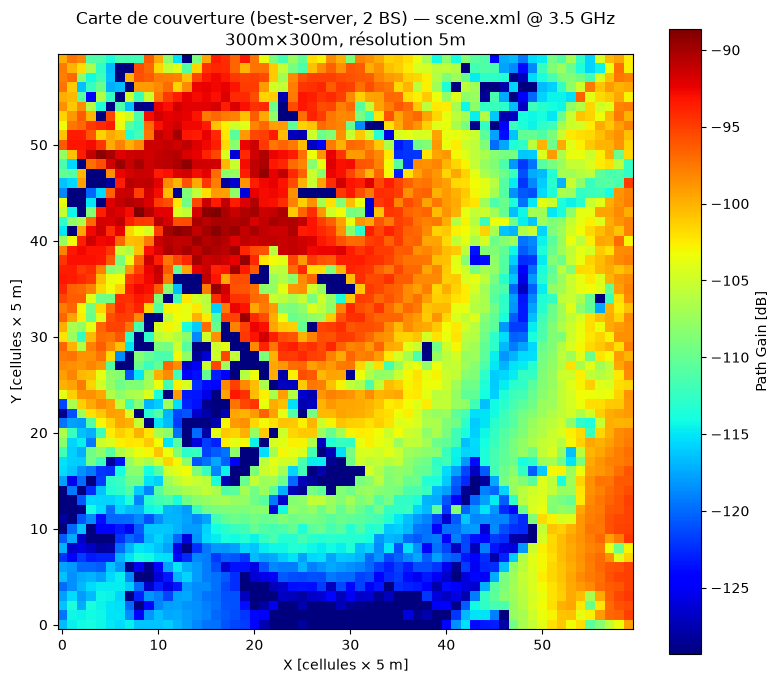

Carte de couverture sauvegardée → radio_map_scene.png


In [9]:
rm_solver = RadioMapSolver()

print("Calcul de la carte de couverture...")
t0 = time.time()

# RadioMapSolver 2.x : center/size/cell_size sont des params directs du call
# PAS de radio_map= ; pas de num_samples= (c'est samples_per_tx=)
radio_map = rm_solver(
    scene,
    center=[49.5, -38.5, 1.5],     # plan horizontal à 1.5 m (hauteur UE), centré sur la scène
    orientation=[0., 0., 0.],
    size=[300., 300.],              # 300 m × 300 m
    cell_size=[5., 5.],            # résolution 5 m
    max_depth=MAX_DEPTH,
    samples_per_tx=int(5e5),
    diffuse_reflection=False,
    los=True,
    specular_reflection=True,
    diffraction=False,
    seed=42,
)

print(f"Carte calculée en {time.time()-t0:.2f} s")

# path_gain shape : [num_tx, cells_y, cells_x] — avec plusieurs BS, on combine en
# "best server" (max linéaire par cellule) pour la carte de couverture globale.
path_gain_per_tx = np.array(radio_map.path_gain)   # [num_tx, cells_y, cells_x]
path_gain_combined = path_gain_per_tx.max(axis=0)  # meilleure BS par cellule
path_gain_db = 10 * np.log10(path_gain_combined + 1e-30)
print(f"Grille : {path_gain_db.shape[0]}×{path_gain_db.shape[1]} cellules ({path_gain_per_tx.shape[0]} BS combinées) | "
      f"Path gain : [{path_gain_db[path_gain_db>-200].min():.1f}, {path_gain_db.max():.1f}] dB")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    path_gain_db,
    origin="lower",
    cmap="jet",
    vmin=np.percentile(path_gain_db[path_gain_db > -200], 5),
    vmax=path_gain_db.max(),
)
plt.colorbar(im, ax=ax, label="Path Gain [dB]")
ax.set_title(f"Carte de couverture (best-server, {path_gain_per_tx.shape[0]} BS) — scene.xml @ {FREQUENCY_HZ/1e9:.1f} GHz\n"
             f"300m×300m, résolution 5m", fontsize=12)
ax.set_xlabel("X [cellules × 5 m]")
ax.set_ylabel("Y [cellules × 5 m]")
fig.tight_layout()
plt.savefig(WORKSPACE / "radio_map_scene.png", dpi=150, bbox_inches="tight")
plt.show()
print("Carte de couverture sauvegardée → radio_map_scene.png")

### Visualisation 3D de la carte de couverture

Même principe que pour les trajets : `scene.render(camera=..., radio_map=radio_map)` en statique, `scene.preview(radio_map=radio_map)` en interactif live.

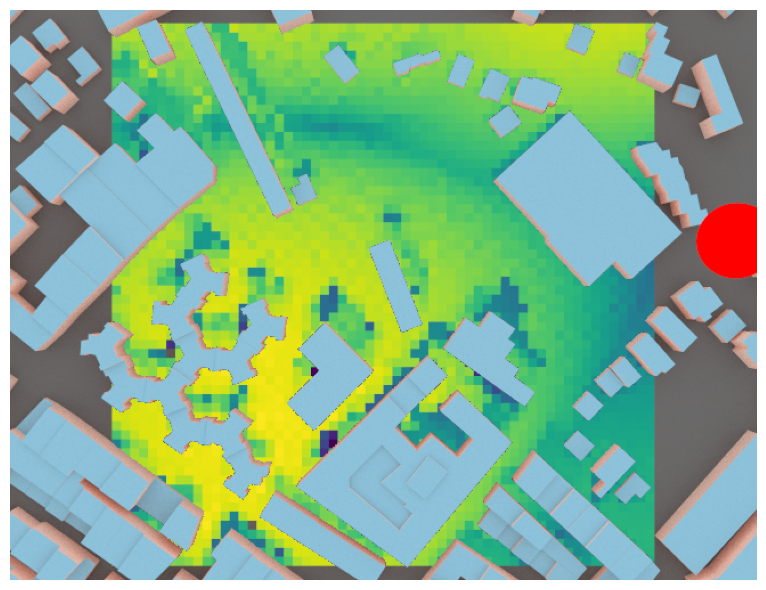

In [10]:
# Caméra dédiée en vue de dessus, pour bien cadrer le plan de couverture 300x300 m
top_cam = Camera(
    position=[center_x, center_y, 500],
    look_at=[center_x, center_y, 0.0],
)

if no_preview:
    scene.render(camera=top_cam, radio_map=radio_map, num_samples=256)
else:
    scene.preview(radio_map=radio_map)

## 9. Paramètres ISAC — Sorties pour la Phase 3

Le ISAC (Integrated Sensing And Communications) exploite les paramètres de canal :
- **Délais** τᵢ → distance des cibles (range)
- **DoA** θᵢ, φᵢ → direction d'arrivée (localisation angulaire)
- **Doppler** fΔ,ᵢ → vitesse radiale (si objets mobiles)
- **Puissances** |aᵢ|² → intensité de réflexion (matériau, distance)

In [11]:
import warnings

isac_params = []

for rx_i in range(num_rx):
    tau_sel  = tau_cir[rx_i, 0, :]                         # [num_paths]
    a_sel    = a_complex[rx_i, :, 0, :, :, 0]              # [rx_ant, tx_ant, paths]
    power_all = np.abs(a_sel)**2
    power_mean = power_all.mean(axis=(0, 1))                # moyenne antennes → [paths]

    valid    = tau_sel >= 0
    tau_v    = tau_sel[valid]
    power_v  = power_mean[valid]
    psum     = power_v.sum() + 1e-30

    # Delay spread (RMS)
    mean_tau = np.sum(power_v * tau_v) / psum
    rms_ds   = np.sqrt(np.sum(power_v * (tau_v - mean_tau)**2) / psum)

    # DoA : theta_t / phi_t si disponibles
    doa_theta, doa_phi = None, None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            doa_theta = np.array(paths.theta_t)[rx_i, 0, :][valid]
            doa_phi   = np.array(paths.phi_t)[rx_i, 0, :][valid]
        except Exception:
            pass

    rec = {
        "rx": f"ue{rx_i}",
        "tx": "bs0",
        "position_rx": RX_POSITIONS[rx_i],
        "num_valid_paths": int(valid.sum()),
        "delays_ns": (tau_v * 1e9).tolist(),
        "powers_db": (10 * np.log10(power_v + 1e-30)).tolist(),
        "total_power_db": float(10 * np.log10(psum)),
        "rms_delay_spread_ns": float(rms_ds * 1e9),
    }
    if doa_theta is not None:
        rec["doa_theta_deg"] = np.degrees(doa_theta).tolist()
        rec["doa_phi_deg"]   = np.degrees(doa_phi).tolist()

    isac_params.append(rec)
    print(f"UE{rx_i}: {rec['num_valid_paths']} trajets | "
          f"P_tot={rec['total_power_db']:.1f} dB | "
          f"DS_rms={rec['rms_delay_spread_ns']:.1f} ns")

print("\nParamètres ISAC extraits.")

UE0: 153 trajets | P_tot=-109.9 dB | DS_rms=29.3 ns
UE1: 43 trajets | P_tot=-111.0 dB | DS_rms=92.7 ns
UE2: 101 trajets | P_tot=-110.6 dB | DS_rms=39.9 ns
UE3: 138 trajets | P_tot=-119.6 dB | DS_rms=850.7 ns
UE4: 64 trajets | P_tot=-116.8 dB | DS_rms=173.9 ns
UE5: 142 trajets | P_tot=-113.9 dB | DS_rms=2515.5 ns

Paramètres ISAC extraits.


## 10. Export Phase 2 → JSON (handoff vers Phase 3)

In [12]:
phase2_summary = {
    "project": "SDM-VA-ISAC",
    "phase": 2,
    "scene_xml": str(SCENE_XML),
    "mitsuba_variant": mi.variant(),
    "sionna_version": SIONNA_VERSION,
    "frequency_hz": float(FREQUENCY_HZ),
    "bandwidth_hz": float(BANDWIDTH_HZ),
    "max_depth": int(MAX_DEPTH),
    "tx_position": TX_POS,
    "rx_positions": RX_POSITIONS,
    "a_shape": list(a_complex.shape),
    "tau_shape": list(tau_cir.shape),
    "isac_per_link": isac_params,
    "validation": {
        "scene_loaded": True,
        "paths_found": int((tau_cir >= 0).sum()) > 0,
        "cir_extracted": True,
        "pdp_generated": True,
    }
}

out_path = WORKSPACE / "phase2_sionna_rt_summary.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(phase2_summary, f, indent=2)

print(f"Résumé Phase 2 sauvegardé → {out_path}")

v = phase2_summary["validation"]
print("\n=== VALIDATION PHASE 2 ===")
for k, ok in v.items():
    icon = "✓" if ok else "✗"
    print(f"  {icon}  {k}")

if all(v.values()):
    print("\n>>> Phase 2 VALIDÉE — Prêt pour la Phase 3 (fusion multimodale) <<<")
else:
    print("\n>>> Certains critères non satisfaits — vérifier les erreurs ci-dessus")

Résumé Phase 2 sauvegardé → C:\Users\AdminFix\Desktop\PFA\phase2_sionna_rt_summary.json

=== VALIDATION PHASE 2 ===
  ✓  scene_loaded
  ✓  paths_found
  ✓  cir_extracted
  ✓  pdp_generated

>>> Phase 2 VALIDÉE — Prêt pour la Phase 3 (fusion multimodale) <<<
